# EDA - Dataset Tickets de Support Multilingue

Analyse exploratoire minimaliste mais essentielle avant la mise en place du système RAG.  
**Objectifs :**
1. Comprendre la structure et le contenu du dataset
2. Identifier les valeurs manquantes et anomalies
3. Analyser les distributions des variables catégorielles (type, queue, priority, language, tags)
4. Évaluer la qualité des champs textuels (subject, body, answer)
5. Formuler des recommandations de nettoyage pour le pipeline RAG

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)

## 1. Chargement et apercu general

In [3]:
df = pd.read_csv("aa_dataset-tickets-multi-lang-5-2-50-version.csv")
print(f"Shape : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head(3)

Shape : 28587 lignes x 16 colonnes


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komp...",Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroff...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management ...","Thank you for reaching out, <name>. We are aware of the outage affecting the centralized account management system, ...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed informati...","Thank you for your inquiry. Our products support integration with Amazon Alexa, Google Assistant, and Apple HomeKit....",Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   24749 non-null  str  
 1   body      28587 non-null  str  
 2   answer    28580 non-null  str  
 3   type      28587 non-null  str  
 4   queue     28587 non-null  str  
 5   priority  28587 non-null  str  
 6   language  28587 non-null  str  
 7   version   28587 non-null  int64
 8   tag_1     28587 non-null  str  
 9   tag_2     28574 non-null  str  
 10  tag_3     28451 non-null  str  
 11  tag_4     25529 non-null  str  
 12  tag_5     14545 non-null  str  
 13  tag_6     5874 non-null   str  
 14  tag_7     2040 non-null   str  
 15  tag_8     565 non-null    str  
dtypes: int64(1), str(15)
memory usage: 3.5 MB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
subject,24749,24749,Wesentlicher Sicherheitsvorfall,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,28587,28587,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komp...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
answer,28580,28580,Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroff...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,28587,4,Incident,11466,NaN,NaN,NaN,NaN,NaN,NaN,NaN
queue,28587,10,Technical Support,8362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,28587,3,medium,11515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,28587,2,en,16338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
version,28587.0,NaN,NaN,NaN,278.382027,165.962935,51.0,52.0,400.0,400.0,400.0
tag_1,28587,116,Security,5880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tag_2,28574,256,Performance,5903,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Valeurs manquantes

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"manquantes": missing, "%": missing_pct}).sort_values("%", ascending=False)
missing_df[missing_df["manquantes"] > 0]

,manquantes,%
tag_8,28022,98.02
tag_7,26547,92.86
tag_6,22713,79.45
tag_5,14042,49.12
subject,3838,13.43
tag_4,3058,10.70
tag_3,136,0.48
tag_2,13,0.05
answer,7,0.02


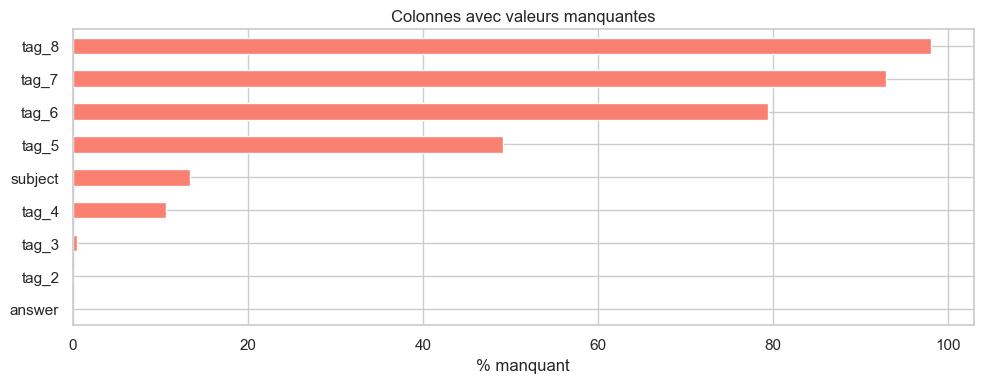

In [7]:
# Visualisation des valeurs manquantes
fig, ax = plt.subplots(figsize=(10, 4))
missing_to_plot = missing_df[missing_df["manquantes"] > 0].sort_values("%")
if not missing_to_plot.empty:
    missing_to_plot["%"].plot.barh(ax=ax, color="salmon")
    ax.set_xlabel("% manquant")
    ax.set_title("Colonnes avec valeurs manquantes")
    plt.tight_layout()
    plt.show()
else:
    print("Aucune valeur manquante dans le dataset.")

## 3. Doublons

In [8]:
n_dup_exact = df.duplicated().sum()
n_dup_body = df.duplicated(subset=["body"]).sum()
n_dup_subject = df.duplicated(subset=["subject"]).sum()

print(f"Doublons exacts (toutes colonnes) : {n_dup_exact}")
print(f"Doublons sur 'body'               : {n_dup_body}")
print(f"Doublons sur 'subject'             : {n_dup_subject}")

Doublons exacts (toutes colonnes) : 0
Doublons sur 'body'               : 0
Doublons sur 'subject'             : 3837


In [9]:
# Exemple de sujets les plus frequents (doublons potentiels)
subject_counts = df["subject"].value_counts()
print("Top 10 sujets les plus frequents :")
subject_counts.head(10)

Top 10 sujets les plus frequents :


subject
Wesentlicher Sicherheitsvorfall                                           1
Account Disruption                                                        1
Query About Smart Home System Integration Features                        1
Inquiry Regarding Invoice Details                                         1
Question About Marketing Agency Software Compatibility                    1
Feature Query                                                             1
System Interruptions                                                      1
Connectivity Problems with Printer on MacBook Pro                         1
Anfrage nach detaillierten Angaben zur Systemarchitektur der Plattform    1
Anfrage zur Klärung der Auswirkungen eines Serviceausfalls                1
Name: count, dtype: int64

## 4. Variables categorielles

In [10]:
cat_cols = ["type", "queue", "priority", "language"]
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(f"  Valeurs uniques : {df[col].nunique()}")
    print(df[col].value_counts())


--- type ---
  Valeurs uniques : 4
type
Incident    11466
Request      8187
Problem      6012
Change       2922
Name: count, dtype: int64

--- queue ---
  Valeurs uniques : 10
queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64

--- priority ---
  Valeurs uniques : 3
priority
medium    11515
high      11178
low        5894
Name: count, dtype: int64

--- language ---
  Valeurs uniques : 2
language
en    16338
de    12249
Name: count, dtype: int64


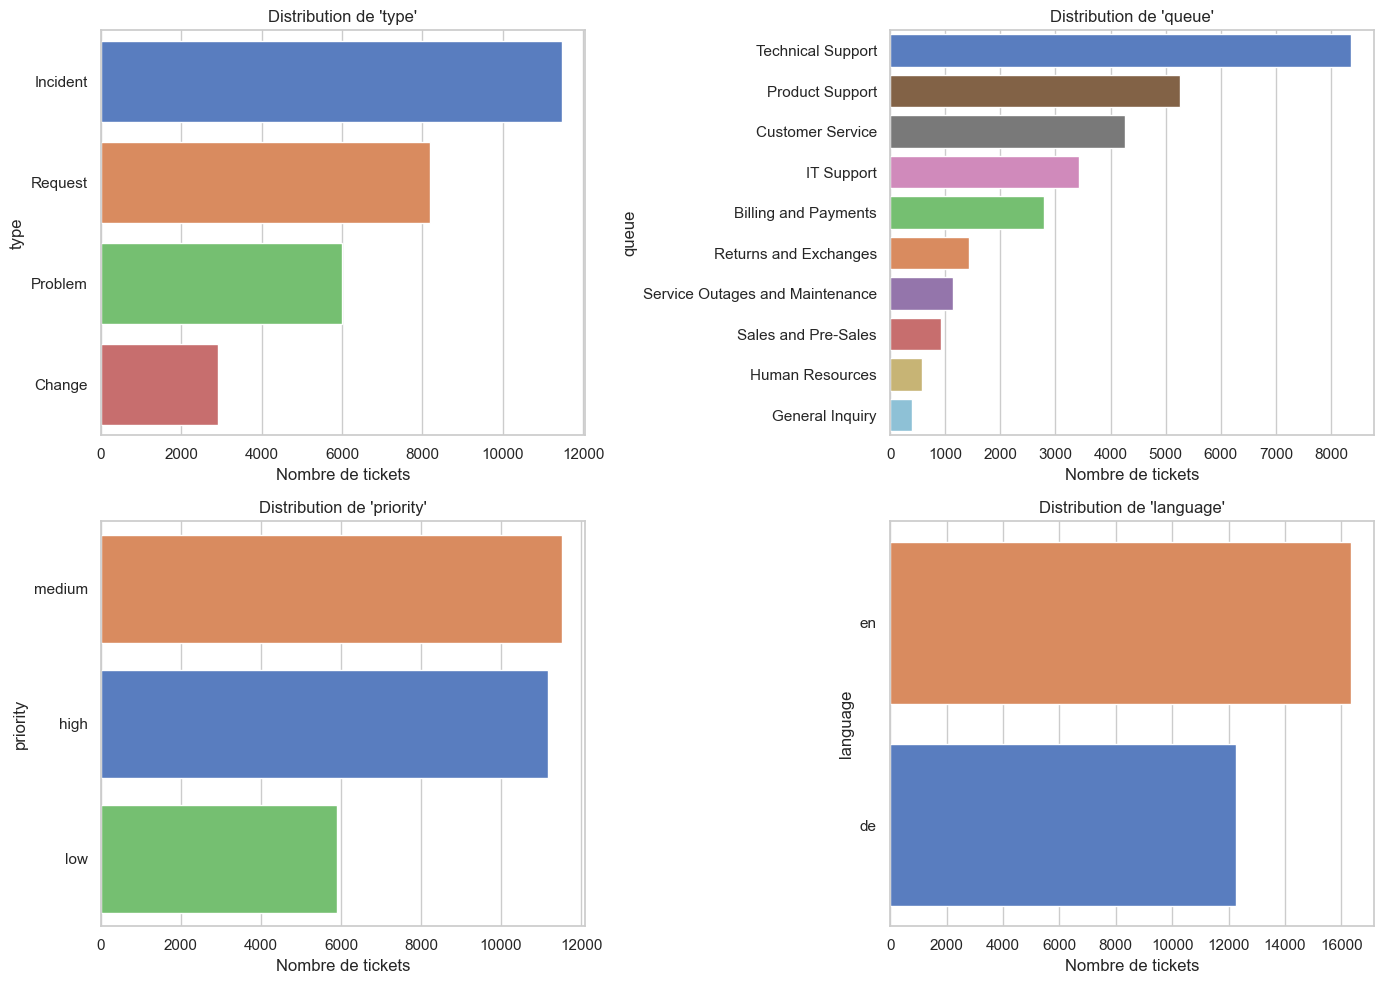

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=ax, hue=col, legend=False)
    ax.set_title(f"Distribution de '{col}'")
    ax.set_xlabel("Nombre de tickets")

plt.tight_layout()
plt.show()

In [12]:
# Croisement type x priority
ct = pd.crosstab(df["type"], df["priority"], normalize="index").round(3) * 100
print("Repartition priority par type (%) :")
ct

Repartition priority par type (%) :


priority,high,low,medium
type,,,
Change,40.0,19.6,40.4
Incident,43.0,18.9,38.1
Problem,39.1,20.6,40.3
Request,33.3,23.5,43.2


In [13]:
# Croisement type x language
ct_lang = pd.crosstab(df["type"], df["language"], normalize="index").round(3) * 100
print("Repartition language par type (%) :")
ct_lang

Repartition language par type (%) :


language,de,en
type,,
Change,41.6,58.4
Incident,42.7,57.3
Problem,43.5,56.5
Request,43.0,57.0


## 5. Analyse des tags

In [14]:
tag_cols = [c for c in df.columns if c.startswith("tag_")]

# Nombre de tags renseignes par ticket
df["nb_tags"] = df[tag_cols].notna().sum(axis=1)
print("Distribution du nombre de tags par ticket :")
print(df["nb_tags"].value_counts().sort_index())
print(f"\nMoyenne : {df['nb_tags'].mean():.2f}")

Distribution du nombre de tags par ticket :
nb_tags
1       13
2      123
3     2922
4    10984
5     8671
6     3834
7     1475
8      565
Name: count, dtype: int64

Moyenne : 4.69


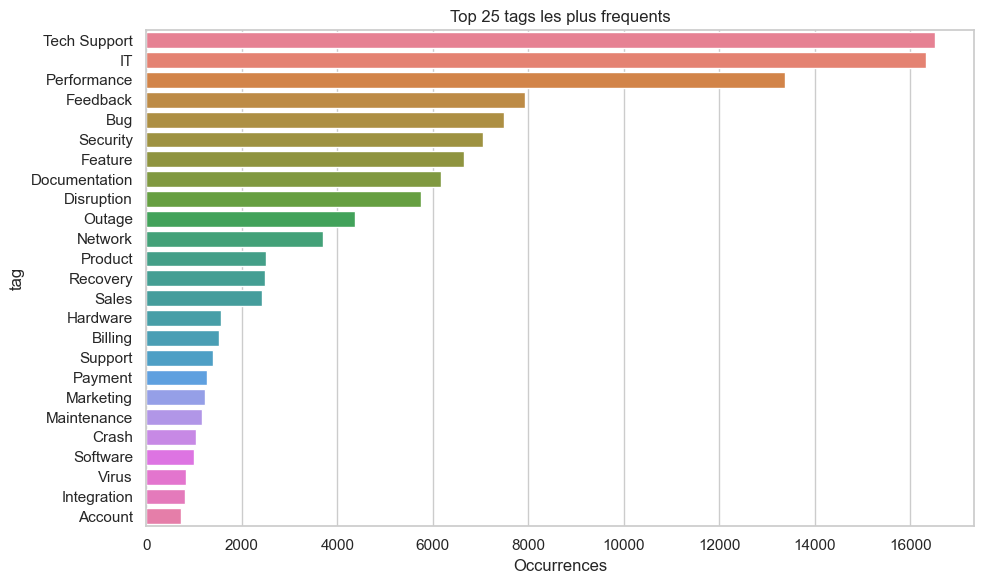


Nombre total de tags distincts : 1255


In [15]:
# Tags les plus frequents (tous tag_* confondus)
all_tags = df[tag_cols].values.flatten()
all_tags = [t for t in all_tags if pd.notna(t)]
tag_freq = Counter(all_tags)

tag_freq_df = pd.DataFrame(tag_freq.most_common(25), columns=["tag", "count"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x="count", y="tag", data=tag_freq_df, ax=ax, hue="tag", legend=False)
ax.set_title("Top 25 tags les plus frequents")
ax.set_xlabel("Occurrences")
plt.tight_layout()
plt.show()

print(f"\nNombre total de tags distincts : {len(tag_freq)}")

## 6. Colonne `version`

In [16]:
print(f"Valeurs uniques de 'version' : {df['version'].nunique()}")
print(df["version"].value_counts())

Valeurs uniques de 'version' : 3
version
400    18599
52      9119
51       869
Name: count, dtype: int64


## 7. Analyse des champs textuels

In [17]:
text_cols = ["subject", "body", "answer"]

for col in text_cols:
    lengths = df[col].dropna().str.len()
    word_counts = df[col].dropna().str.split().str.len()
    print(f"\n--- {col} ---")
    print(f"  Longueur (chars) : min={lengths.min()}, median={lengths.median():.0f}, max={lengths.max()}, mean={lengths.mean():.0f}")
    print(f"  Nb mots          : min={word_counts.min()}, median={word_counts.median():.0f}, max={word_counts.max()}, mean={word_counts.mean():.0f}")


--- subject ---
  Longueur (chars) : min=3, median=42, max=675, mean=45
  Nb mots          : min=1, median=5, max=77, mean=5

--- body ---
  Longueur (chars) : min=6, median=386, max=1469, mean=387
  Nb mots          : min=1, median=54, max=175, mean=53

--- answer ---
  Longueur (chars) : min=4, median=390, max=1006, mean=387
  Nb mots          : min=1, median=58, max=135, mean=57


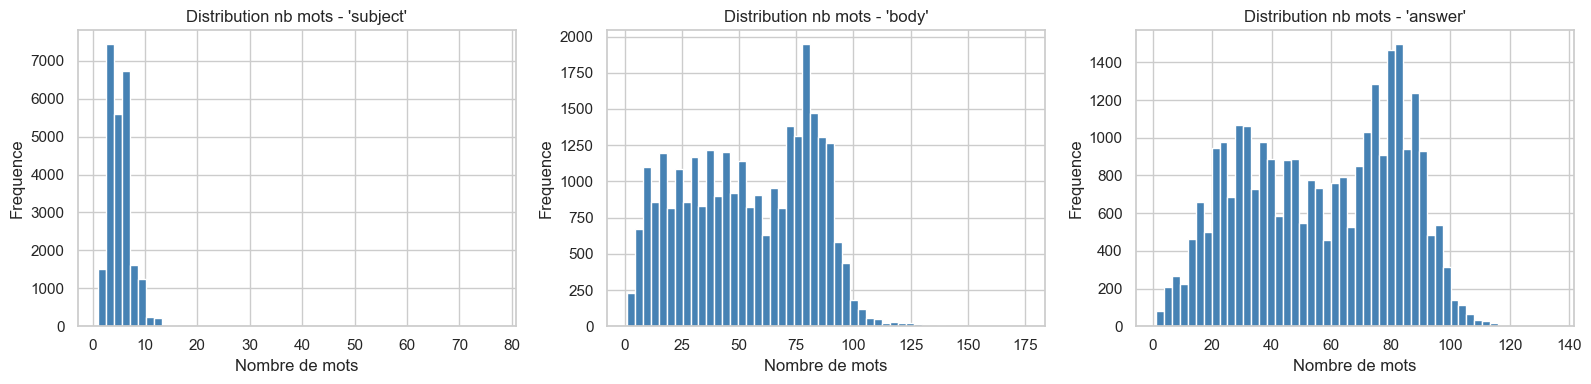

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, text_cols):
    word_counts = df[col].dropna().str.split().str.len()
    ax.hist(word_counts, bins=50, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribution nb mots - '{col}'")
    ax.set_xlabel("Nombre de mots")
    ax.set_ylabel("Frequence")

plt.tight_layout()
plt.show()

In [19]:
# Detection de patterns problematiques dans les textes
print("=== Verifications qualite texte ===")

# Textes vides ou tres courts
for col in text_cols:
    short = df[col].dropna().str.split().str.len() < 3
    print(f"  '{col}' avec < 3 mots : {short.sum()}")

# Placeholders detectes (ex: <name>, [Your Name], etc.)
placeholder_pattern = r"<[a-z_]+>|\[Your Name\]|\[your name\]"
for col in text_cols:
    has_placeholder = df[col].dropna().str.contains(placeholder_pattern, regex=True, flags=re.IGNORECASE)
    print(f"  '{col}' avec placeholders (<name>, [Your Name]...) : {has_placeholder.sum()}")

=== Verifications qualite texte ===
  'subject' avec < 3 mots : 1519
  'body' avec < 3 mots : 61
  'answer' avec < 3 mots : 29
  'subject' avec placeholders (<name>, [Your Name]...) : 0
  'body' avec placeholders (<name>, [Your Name]...) : 1187
  'answer' avec placeholders (<name>, [Your Name]...) : 13774


In [20]:
# Exemples de placeholders dans body
mask = df["body"].str.contains(placeholder_pattern, regex=True, flags=re.IGNORECASE, na=False)
if mask.any():
    print("Exemples de tickets avec placeholders dans 'body' :")
    display(df.loc[mask, ["subject", "body"]].head(3))

Exemples de tickets avec placeholders dans 'body' :


,subject,body
38,Inquiry for Guidance on Smart Water Leak Detector Sensor Setup,"Dear Customer Support,\n\nI am looking for comprehensive instructions on how to configure and integrate the Smart Wa..."
42,Alert for Unauthorized Entry,"Dear Customer Support,\n\nI have recently been notified of attempts at unauthorized entry into my IoT gadgets. This ..."
67,Problem Report,"Customer Support,\n\nI am facing difficulties with the centralized account administration process. Although the feat..."


In [21]:
# Presence de caracteres speciaux / encodage suspect
weird_chars = r"[\x00-\x08\x0b\x0c\x0e-\x1f]"
for col in text_cols:
    has_weird = df[col].dropna().str.contains(weird_chars, regex=True)
    print(f"  '{col}' avec caracteres de controle : {has_weird.sum()}")

  'subject' avec caracteres de controle : 0
  'body' avec caracteres de controle : 0
  'answer' avec caracteres de controle : 0


## 8. Distribution linguistique des textes

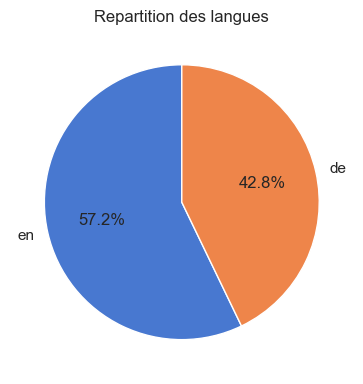

In [22]:
# Repartition des langues
lang_dist = df["language"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
lang_dist.plot.pie(ax=ax, autopct="%1.1f%%", startangle=90)
ax.set_ylabel("")
ax.set_title("Repartition des langues")
plt.tight_layout()
plt.show()

In [23]:
# Longueur moyenne du body par langue
df["body_word_count"] = df["body"].str.split().str.len()

print("Statistiques nb mots (body) par langue :")
df.groupby("language")["body_word_count"].describe().round(1)

Statistiques nb mots (body) par langue :


,count,mean,std,min,25%,50%,75%,max
language,,,,,,,,
de,12249.0,53.0,28.8,1.0,28.0,52.0,80.0,175.0
en,16338.0,53.9,26.9,1.0,31.0,55.0,78.0,168.0


## 9. Coherence queue / type / tags

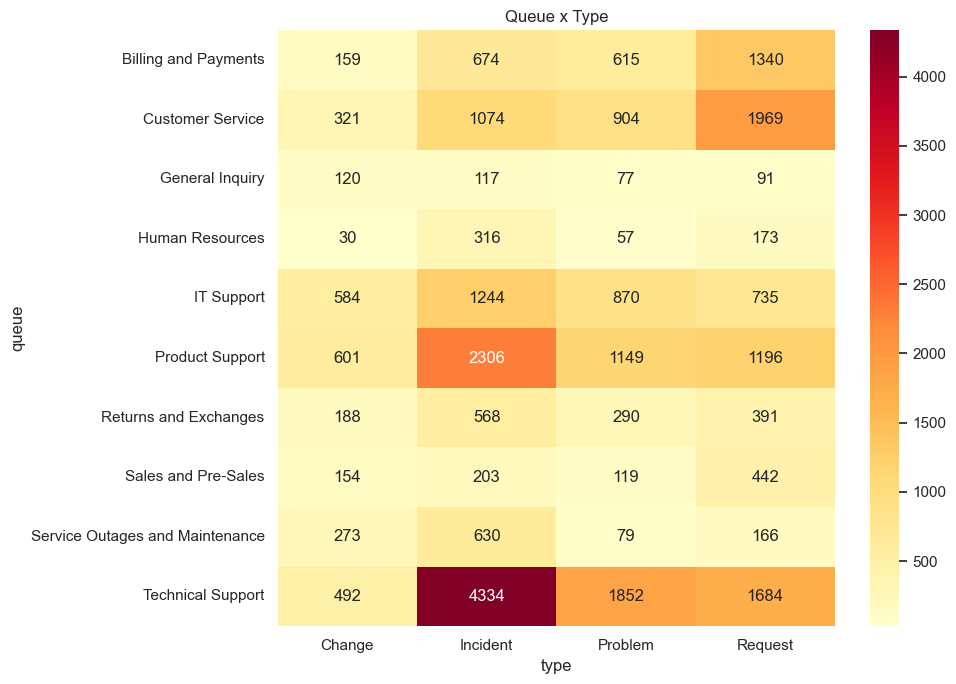

In [24]:
# Heatmap queue x type
ct_qt = pd.crosstab(df["queue"], df["type"])

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(ct_qt, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Queue x Type")
plt.tight_layout()
plt.show()

## 10. Synthese et recommandations nettoyage pour le RAG

In [25]:
print("""
       SYNTHESE EDA - TICKETS SUPPORT

STRUCTURE :
  - {n} tickets, {c} colonnes
  - 3 champs textuels : subject, body, answer
  - 4 metadonnees categoriques : type, queue, priority, language
  - 8 colonnes tags (tag_1 a tag_8), remplissage variable
  - 1 colonne version

QUALITE :
  - Doublons exacts   : {dup}
  - Doublons sur body : {dup_b}
  - Valeurs manquantes concentrees sur tag_5 a tag_8
  - Textes contiennent des placeholders (<name>, <tel_num>, [Your Name])

RECOMMANDATIONS NETTOYAGE POUR LE RAG :
  1. Deduplication : supprimer doublons exacts
  2. Fusionner les tags en une seule liste par ticket (ignorer NaN)
  3. Normaliser/supprimer les placeholders avant indexation
  4. Combiner subject + body comme document source pour l'ingestion
  5. Utiliser type, queue, priority, language, tags comme metadonnees filtrables
  6. Verifier l'utilite de la colonne 'version' (semble constante)
""".format(
    n=len(df),
    c=df.shape[1] - 2,  # sans les colonnes ajoutees
    dup=n_dup_exact,
    dup_b=n_dup_body,
))


       SYNTHESE EDA - TICKETS SUPPORT

STRUCTURE :
  - 28587 tickets, 16 colonnes
  - 3 champs textuels : subject, body, answer
  - 4 metadonnees categoriques : type, queue, priority, language
  - 8 colonnes tags (tag_1 a tag_8), remplissage variable
  - 1 colonne version

QUALITE :
  - Doublons exacts   : 0
  - Doublons sur body : 0
  - Valeurs manquantes concentrees sur tag_5 a tag_8
  - Textes contiennent des placeholders (<name>, <tel_num>, [Your Name])

RECOMMANDATIONS NETTOYAGE POUR LE RAG :
  1. Deduplication : supprimer doublons exacts
  2. Fusionner les tags en une seule liste par ticket (ignorer NaN)
  3. Normaliser/supprimer les placeholders avant indexation
  4. Combiner subject + body comme document source pour l'ingestion
  5. Utiliser type, queue, priority, language, tags comme metadonnees filtrables
  6. Verifier l'utilite de la colonne 'version' (semble constante)

